####The stock market is a place where people buy and sell shares of companies. It's like a marketplace where investors can trade stocks and other types of investments. There are rules and regulations in place to ensure fair and orderly transactions. Different stock markets exist in different countries or regions, allowing people to trade stocks and other securities.

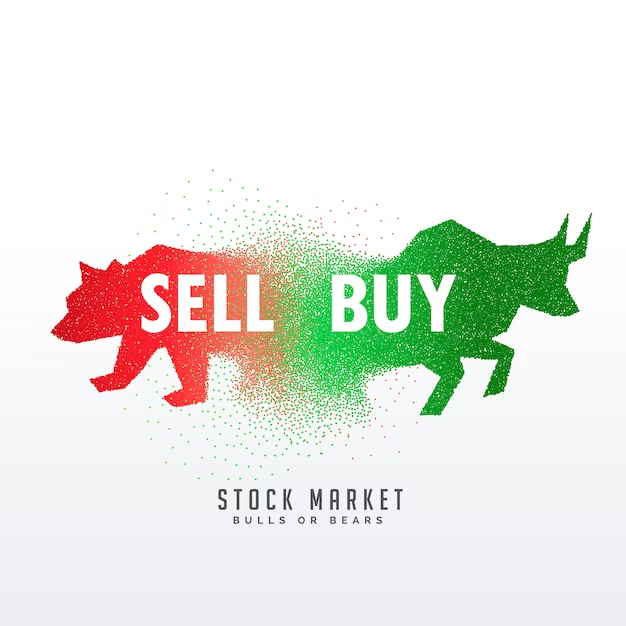

#Problem Statement:
##This dataset contains the stock price values of Netflix from 2018 to 2022.


##The aim of this project is to use ARIMA Modelling to predict these stock prices as well as forecast the stock price values for the next 30 days.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("/content//NFLX.csv") #reading the dataset
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


####To better understand the problem at hand, let's establish our objective. Stock market analysis can be broadly divided into two categories: Fundamental Analysis and Technical Analysis.

####1. Fundamental Analysis: This involves assessing a company's potential profitability by analyzing its current business environment and financial performance.

####2. Technical Analysis: This involves studying charts and using statistical data to identify patterns and trends in the stock market.

####For this article, our focus will be on technical analysis. We will be using a dataset containing Netflix stock prices from February 2018 to Februrary 2022 to develop a model that can predict future stock prices. Let's get started!

####Here are the key points to understand:

####Dataset Variables: The dataset includes several variables such as Date, Open, High, Low, Close, Adj Close and volume.

####1. Open and Close represent the starting and final prices of the stock for a given day.
####2. High and Low indicate the maximum and minimum prices of the stock during the day.
####3. Volume represents the number of shares traded on that day.

####Weekend and Holiday Considerations: The stock market is closed on weekends and public holidays. In the dataset, certain date values are missing, such as 10/2/2018, 11/2/2018, and 24/2/2018.

####1. 11/2/2018 and 24/2/2018 are missing because they fall on the weekend.

####2. Target Variable: The calculation of profit or loss is typically based on the closing price of a stock for the day. Therefore, in this analysis, we will consider the Adj Close price as the target variable.


##By keeping these points in mind, we can proceed with our analysis.

In [ ]:
df = df.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1) #extracting the adj_close column
df

,Date,Adj Close
0,2018-02-05,254.259995
1,2018-02-06,265.720001
2,2018-02-07,264.559998
3,2018-02-08,250.100006
4,2018-02-09,249.470001
...,...,...
1004,2022-01-31,427.140015
1005,2022-02-01,457.130005
1006,2022-02-02,429.480011
1007,2022-02-03,405.600006


In [ ]:
df = df.groupby('Date')['Adj Close'].sum().reset_index()
# Group the DataFrame by 'Date' column, calculate the sum of 'Adj Close' values for each date,
# and reset the index to obtain a new DataFrame with 'Date' and 'Adj Close' columns.

In [ ]:
df.Date = pd.to_datetime(df.Date)  # Convert the 'Date' column to datetime format
df.head()

,Date,Adj Close
0,2018-02-05,254.259995
1,2018-02-06,265.720001
2,2018-02-07,264.559998
3,2018-02-08,250.100006
4,2018-02-09,249.470001


In [ ]:
df.set_index(['Date'], inplace=True)  # Set 'Date' as the index of the DataFrame
df.head()

,Adj Close
Date,
2018-02-05,254.259995
2018-02-06,265.720001
2018-02-07,264.559998
2018-02-08,250.100006
2018-02-09,249.470001



###Plotting the Target Variable: To understand the behavior of the target variable in our data, we can create a plot representing the closing prices over time.

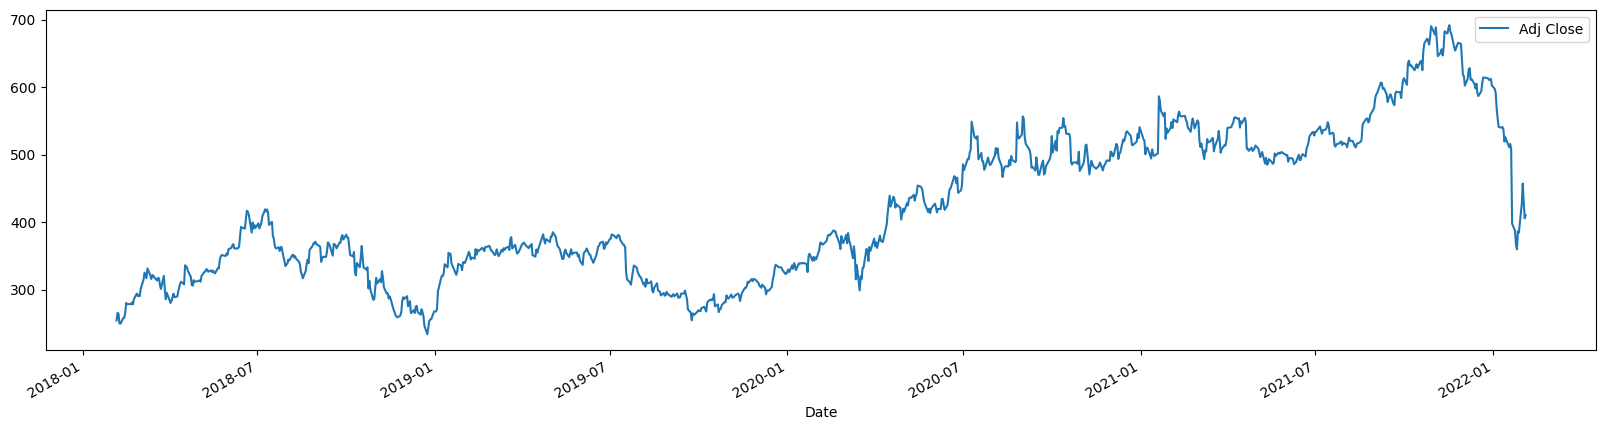

In [ ]:
df.plot(figsize=(20,5))
plt.show()

In [ ]:
#f- format while print statement is used

from statsmodels.tsa.stattools import adfuller

#ADF Test - if the p-value < 0.05 - Data is stationary
result = adfuller(df)

print(f'p-value={result[1]}')

if(result[1]>0.05):
    print("The series is not stationary")
else:
    print("series is stationary")

p-value=0.3742289256820759
The series is not stationary


In [ ]:
diff1 = df - df.shift(1)  # Calculate the difference between consecutive rows
diff1 = diff1.dropna()  # Remove the first row with NaN values

In [ ]:
#f- format while print statement is used

from statsmodels.tsa.stattools import adfuller

#ADF Test - if the p-value < 0.05 - Data is stationary
result = adfuller(diff1)

print(f'p-value={result[1]}')

if(result[1]>0.05):
    print("The series is not stationary")
else:
    print("series is stationary")

p-value=1.5304022754298515e-26
series is stationary


<Axes: xlabel='Date'>

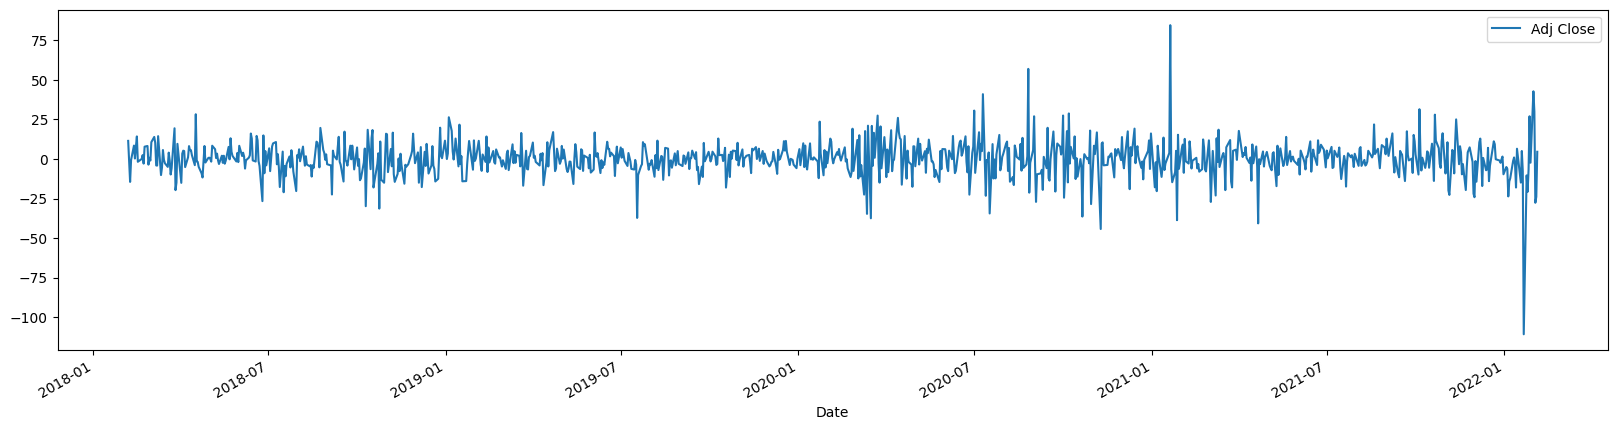

In [ ]:
diff1.plot(figsize=(20,5)) #Stationary Data

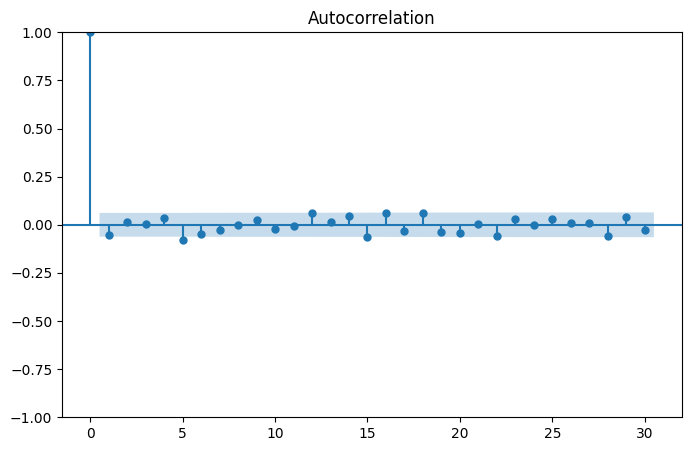

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(8, 5))
# Plot the autocorrelation function (ACF)
plot_acf(diff1['Adj Close'], ax=ax, lags=30)
# Display the plot
plt.show()

In [ ]:
#Number of lags for MA -> 7.

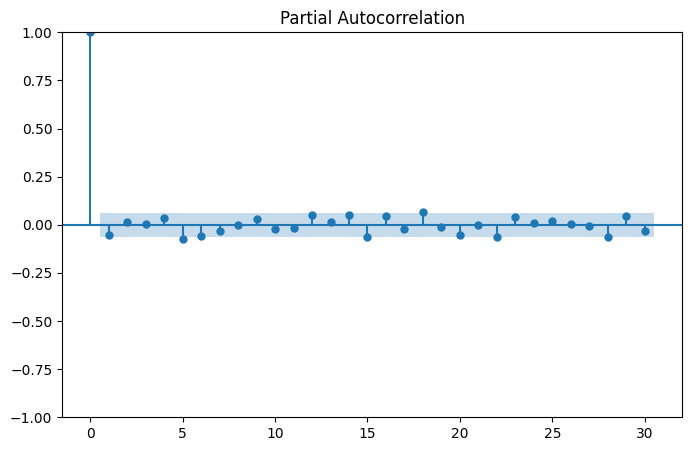

In [ ]:
# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(8, 5))
# Plot the autocorrelation function (ACF)
plot_pacf(diff1['Adj Close'], ax=ax, lags=30)
# Display the plot
plt.show()

In [ ]:
#Number of lags for AR -> 7.

In [ ]:
!pip install pmdarima

In [ ]:
# !pip install numpy==1.23.5

In [ ]:
from pmdarima import auto_arima

In [ ]:
auto=auto_arima(df['Adj Close'])

In [ ]:
auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1009
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3851.903
Date:                Sat, 12 Jul 2025   AIC                           7705.806
Time:                        10:05:42   BIC                           7710.722
Sample:                             0   HQIC                          7707.674
                               - 1009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       122.0953      1.889     64.647      0.000     118.394     125.797
===================================================================================
Ljung-Box (L1) (Q):                   2.64   Jarque-Bera (JB):              9050.50
Prob(Q):                              0.10   Prob(JB):                         0.00
Heteroskedasticity (H):               2.27   Skew:                            -0.63
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
model = ARIMA(df['Adj Close'], order=(0, 1, 0))

In [ ]:
result = model.fit()

In [ ]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Adj Close   No. Observations:                 1009
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -3851.903
Date:                Sat, 12 Jul 2025   AIC                           7705.806
Time:                        10:05:42   BIC                           7710.722
Sample:                             0   HQIC                          7707.674
                               - 1009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       122.0953      1.889     64.647      0.000     118.394     125.797
===================================================================================
Ljung-Box (L1) (Q):                   2.64   Jarque-Bera (JB):              9050.50
Prob(Q):                              0.10   Prob(JB):                         0.00
Heteroskedasticity (H):               2.27   Skew:                            -0.63
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
df['prediction_arima'] = result.predict(start=1, end=1008)

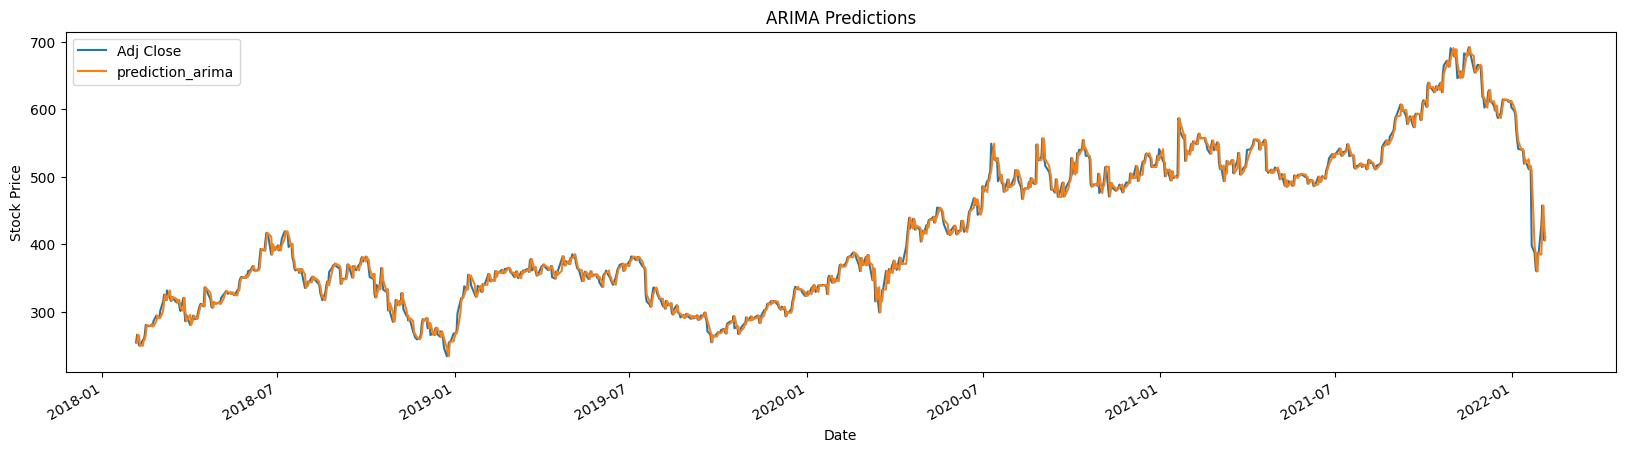

In [ ]:
df[["Adj Close", "prediction_arima"]].plot(figsize=(20, 5))
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('ARIMA Predictions')
plt.show()

In [ ]:
# Generate a 30-day forecast using the fitted ARIMA model, specifying a confidence level of 95%
fc = result.forecast(90, alpha=0.05)

In [ ]:
for i in fc:
    print(round(i, 0))

<Axes: >

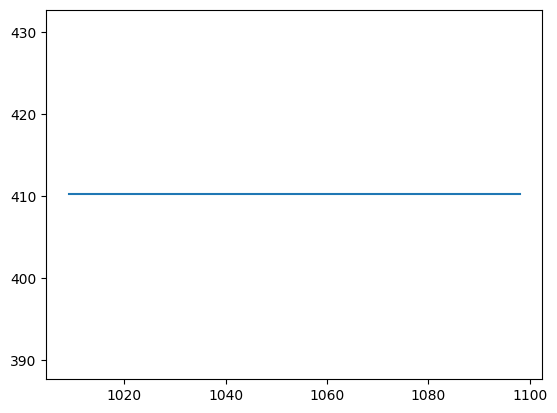

In [ ]:
fc.plot()

In [ ]:
import itertools
import matplotlib.pyplot as plt
# Define p, d, q values to test (for ARIMA)
p = range(0, 7, 1)
d = [0,1]
q = range(0, 7, 1)

# Create combinations: (p, d, q)
pdq = list(itertools.product(p, d, q))

best_aic = float('inf')
best_order = None
best_model = None
pdq

[(0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 0, 3),
 (0, 0, 4),
 (0, 0, 5),
 (0, 0, 6),
 (0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 1, 4),
 (0, 1, 5),
 (0, 1, 6),
 (1, 0, 0),
 (1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 0, 4),
 (1, 0, 5),
 (1, 0, 6),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 0, 4),
 (2, 0, 5),
 (2, 0, 6),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (3, 0, 0),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 0, 4),
 (3, 0, 5),
 (3, 0, 6),
 (3, 1, 0),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (4, 0, 0),
 (4, 0, 1),
 (4, 0, 2),
 (4, 0, 3),
 (4, 0, 4),
 (4, 0, 5),
 (4, 0, 6),
 (4, 1, 0),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (5, 0, 0),
 (5, 0, 1),
 (5, 0, 2),
 (5, 0, 3),
 (5, 0, 4),
 (5, 0, 5),
 (5, 0, 6),
 (5, 1, 0),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5,

### Understanding AIC (Akaike Information Criterion)

When we build models in data science or statistics, we want two main things:

1. **Good performance**: The model should fit the data well.
2. **Simplicity**: The model should not be overly complex.

AIC helps us find the best balance between these two.

---

#### What is AIC?

AIC stands for **Akaike Information Criterion**. It is a score that tells us how good a model is **compared to others**.

- A model that fits the data better gets a lower AIC score.
- A simpler model (with fewer parameters) is preferred.
- AIC **penalizes complexity**, so it avoids overfitting.

---

#### Simple Rule:

**The lower the AIC score, the better the model.**

AIC is useful when we are trying many models (for example, ARIMA models with different parameters), and we want to select the best one.

---

#### Real-Life Analogy:

Imagine you're choosing a car. You want it to:

- Run smoothly (good performance)
- Not have too many fancy parts that might break (simplicity)

Similarly, AIC helps us choose the model that works well and is not too complicated.

---

#### In One Line:

**AIC helps us pick the model that gives accurate results without being too complex.**


In [ ]:
import statsmodels.api as sm
# Try each combination
for order in pdq:
    try:
        model = sm.tsa.ARIMA(df["Adj Close"], order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

print(f"Best ARIMA order: {best_order}")
print(best_model.summary())


Best ARIMA order: (6, 1, 6)
                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 1009
Model:                 ARIMA(6, 1, 6)   Log Likelihood               -3838.361
Date:                Sat, 12 Jul 2025   AIC                           7702.723
Time:                        10:10:09   BIC                           7766.627
Sample:                             0   HQIC                          7727.002
                               - 1009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2226      0.065      3.444      0.001       0.096       0.349
ar.L2          0.6265      0.062     10.130      0.000       0.505       0.748
ar.L3         -1.1327   

In [ ]:
final_model=ARIMA(df['Adj Close'], order=(6, 1, 6))

In [ ]:
final_result = final_model.fit()

In [ ]:
df['prediction_arima_final'] = final_result.predict(start=1, end=1008)

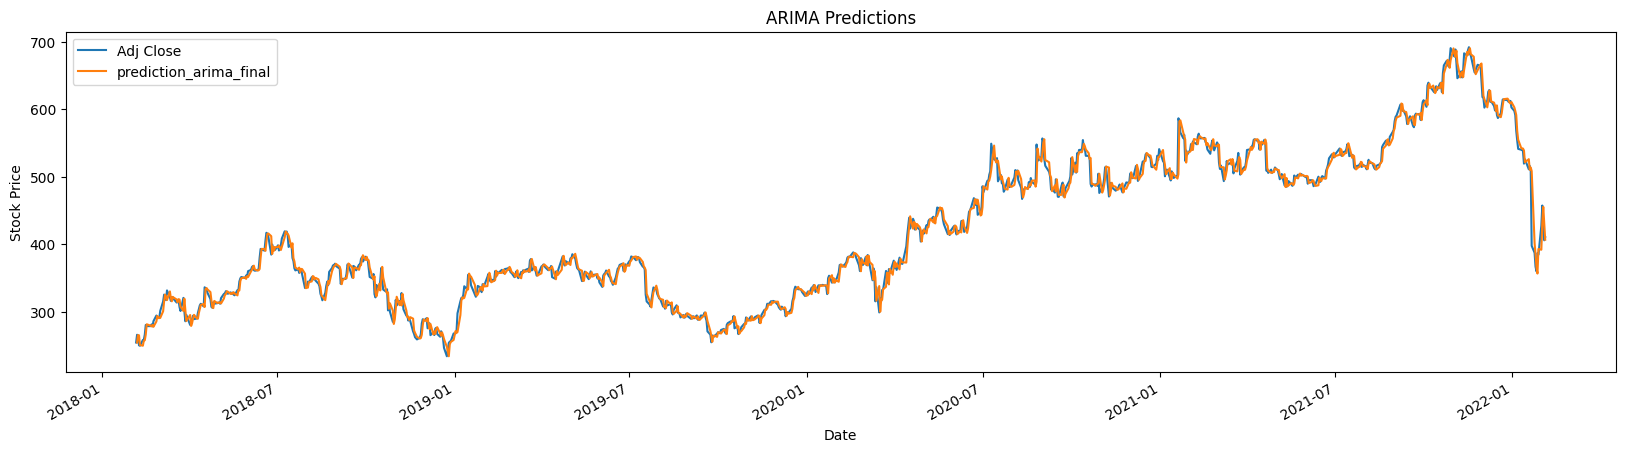

In [ ]:
df[["Adj Close", "prediction_arima_final"]].plot(figsize=(20, 5))
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('ARIMA Predictions')
plt.show()

In [ ]:
fc = final_result.forecast(90, alpha=0.05)

In [ ]:
for i in fc:
    print(round(i, 0))

409.0
400.0
393.0
392.0
396.0
398.0
398.0
400.0
406.0
411.0
412.0
407.0
404.0
403.0
402.0
398.0
394.0
395.0
399.0
403.0
404.0
405.0
407.0
409.0
408.0
404.0
400.0
399.0
399.0
399.0
397.0
399.0
402.0
406.0
406.0
406.0
405.0
406.0
404.0
401.0
398.0
398.0
399.0
401.0
401.0
402.0
404.0
406.0
406.0
404.0
403.0
403.0
402.0
400.0
399.0
399.0
401.0
403.0
403.0
403.0
404.0
405.0
404.0
403.0
401.0
401.0
401.0
401.0
401.0
401.0
403.0
404.0
404.0
404.0
404.0
403.0
403.0
402.0
401.0
401.0
401.0
402.0
402.0
402.0
403.0
404.0
404.0
403.0
403.0
402.0


<Axes: >

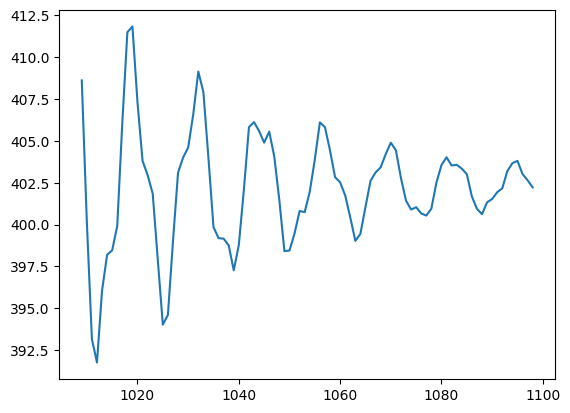

In [ ]:
fc.plot()